# Module 06 - Next-Token Prediction

Use this notebook as the working space for the Module 06 exercises.

1. Read the lesson page (`docs/modules/06-language-models.md`).
2. Open this notebook with `.venv/bin/python scripts/open_notebook.py 06`.
3. Answer the `Question:` / `Answer:` cells below.
4. When you're ready, ask a coding agent to grade your notebook.

Partial work is fine. Blank `Answer: ""` strings are skipped, not counted wrong. If you'd like a hint instead of a grade, write the request inline in the answer string and the agent will tutor first.

In [1]:
from __future__ import annotations

import math
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import torch

import g2c
from g2c.lm import (
    CountsBigramLM,
    MLPLanguageModel,
    NeuralBigramLM,
    get_batch,
    perplexity,
    sample,
    train_lm,
)
from g2c.tokenizer import BPETokenizer

_ = torch.manual_seed(0)
repo_root = Path(g2c.__file__).resolve().parents[1]
experiment_device = "auto"
print("MPS available:", torch.backends.mps.is_available())

MPS available: True


## Before the Notebook

Use the tests to implement the Module 06 library pieces first. The notebook assumes `CountsBigramLM`, `NeuralBigramLM`, `MLPLanguageModel`, `perplexity`, `sample`, and `train_lm` become available as you progress through `tests/test_lm.py`. The corpus comparison later also assumes your Module 04 tokenizer works.

In [2]:
"Run from the terminal: .venv/bin/python -m pytest tests/test_lm.py -x"
"Question: Which Module 06 test is the next one failing, and what implementation does it point at?"
"Answer: "

'Answer: '

In [3]:
test_path = repo_root / "tests" / "test_lm.py"
assert test_path.exists(), f"Could not find {test_path}"

result = subprocess.run(
    [sys.executable, "-m", "pytest", str(test_path), "-q"],
    cwd=repo_root,
    text=True,
    capture_output=True,
)

print(result.stdout)
if result.stderr:
    print(result.stderr)

assert result.returncode == 0, "Module 06 language-model tests are not passing yet."
print("Module 06 language-model tests passed.")

................................................                         [100%]

Module 06 language-model tests passed.


## Exercise 1 - Context Windows and Targets

Language modeling turns one token stream into many supervised examples. Each context window predicts the token immediately after it.

In [4]:
"Question: For ids [4, 7, 1, 3, 9] and context_length=2, what are all possible (context, target) examples?"
"Answer: "

"Question: Why is this called self-supervised data rather than manually labeled data?"
"Answer: "

"Question: What shapes should get_batch return for batch_size=4 and context_length=3?"
"Answer: "

'Answer: '

In [5]:
toy_ids = torch.tensor([4, 7, 1, 3, 9])
context_length = 2

print("All deterministic windows:")
for i in range(len(toy_ids) - context_length):
    context = toy_ids[i : i + context_length].tolist()
    target = toy_ids[i + context_length].item()
    print(f"  {context} -> {target}")

x_batch, y_batch = get_batch(
    torch.arange(20),
    context_length=3,
    batch_size=4,
    generator=torch.Generator().manual_seed(0),
)
print("\nRandom batch contexts:")
print(x_batch)
print("targets:", y_batch.tolist())
assert x_batch.shape == (4, 3)
assert y_batch.shape == (4,)

All deterministic windows:
  [4, 7] -> 1
  [7, 1] -> 3
  [1, 3] -> 9

Random batch contexts:
tensor([[ 7,  8,  9],
        [ 3,  4,  5],
        [12, 13, 14],
        [16, 17, 18]])
targets: [10, 6, 15, 19]


## Exercise 2 - Counts Bigram Model

A counts bigram model learns `P(next | previous)` by tallying adjacent token pairs. No gradients, no hidden layers, just a table.

In [6]:
"Question: In [0, 1, 0, 1, 2], what should counts[0, 1] be? What should counts[1, 0] be?"
"Answer: "

"Question: Why does add-one smoothing prevent unseen next tokens from getting probability zero?"
"Answer: "

"Question: Why does CountsBigramLM.logits return log-probabilities instead of raw counts?"
"Answer: "

'Answer: '

In [7]:
labels = {0: "A", 1: "B", 2: "C", 3: "D"}
tiny_stream = torch.tensor([0, 1, 0, 1, 2, 1, 0, 1])

counts_lm = CountsBigramLM(vocab_size=4, smoothing=1.0)
counts_lm.fit(tiny_stream)

print("Raw counts table: rows are previous tokens, columns are next tokens")
print("      ", "  ".join(labels[i] for i in range(4)))
for prev in range(4):
    row = "  ".join(f"{counts_lm.counts[prev, nxt].item():2d}" for nxt in range(4))
    print(f"prev {labels[prev]}  {row}")

ctx = torch.tensor([0, 1, 2, 3])
probs = counts_lm.logits(ctx).exp()
print("\nSmoothed next-token probabilities:")
for prev, row in zip(ctx.tolist(), probs):
    formatted = ", ".join(f"P({labels[nxt]}|{labels[prev]})={row[nxt].item():.3f}" for nxt in range(4))
    print(formatted)

Raw counts table: rows are previous tokens, columns are next tokens
       A  B  C  D
prev A   0   3   0   0
prev B   2   0   1   0
prev C   0   1   0   0
prev D   0   0   0   0

Smoothed next-token probabilities:
P(A|A)=0.143, P(B|A)=0.571, P(C|A)=0.143, P(D|A)=0.143
P(A|B)=0.429, P(B|B)=0.143, P(C|B)=0.286, P(D|B)=0.143
P(A|C)=0.200, P(B|C)=0.400, P(C|C)=0.200, P(D|C)=0.200
P(A|D)=0.250, P(B|D)=0.250, P(C|D)=0.250, P(D|D)=0.250


## Exercise 3 - Neural Bigram and MLP Shapes

The neural bigram and MLP share the same output contract: logits shaped `(batch, vocab_size)`. The MLP differs by preserving a multi-token context through concatenation.

In [8]:
"Question: Why does NeuralBigramLM need to squeeze a context shaped (B, 1) before embedding?"
"Answer: "

"Question: If an MLP has context_length=3 and embedding_dim=8, what is the flattened hidden-layer input width?"
"Answer: "

"Question: Why does concatenating embeddings preserve order while averaging them does not?"
"Answer: "

'Answer: '

In [9]:
neural_bigram = NeuralBigramLM(vocab_size=10, embedding_dim=4)
bigram_ctx = torch.tensor([[0], [1], [2]])
bigram_logits = neural_bigram(bigram_ctx)
print("neural bigram context:", tuple(bigram_ctx.shape))
print("neural bigram logits:", tuple(bigram_logits.shape))

mlp = MLPLanguageModel(vocab_size=10, context_length=2, embedding_dim=4, hidden_dim=8)
ctx_ab = torch.tensor([[3, 7]])
ctx_ba = torch.tensor([[7, 3]])
logits_ab = mlp(ctx_ab)
logits_ba = mlp(ctx_ba)
max_difference = (logits_ab - logits_ba).abs().max().item()
print("\nMLP context shape:", tuple(ctx_ab.shape))
print("MLP logits shape:", tuple(logits_ab.shape))
print(f"max logit difference between [3, 7] and [7, 3]: {max_difference:.6f}")
assert bigram_logits.shape == (3, 10)
assert logits_ab.shape == logits_ba.shape == (1, 10)
assert max_difference > 1e-3

neural bigram context: (3, 1)
neural bigram logits: (3, 10)

MLP context shape: (1, 2)
MLP logits shape: (1, 10)
max logit difference between [3, 7] and [7, 3]: 0.123580


## Exercise 4 - Perplexity and Autoregressive Sampling

Perplexity evaluates the model on known text. Sampling generates unknown text by repeatedly predicting and appending one token.

In [10]:
"Question: Why should a uniform model over V tokens have perplexity V?"
"Answer: "

"Question: Why does a perfect deterministic model have perplexity 1?"
"Answer: "

"Question: During sampling, why do we feed the newly sampled token back into the next context?"
"Answer: "

'Answer: '

In [11]:
uniform_counts = CountsBigramLM(vocab_size=8, smoothing=1.0)
uniform_eval_ids = torch.randint(0, 8, (200,), generator=torch.Generator().manual_seed(1))
uniform_ppl = perplexity(uniform_counts, uniform_eval_ids)
print(f"uniform counts perplexity: {uniform_ppl:.3f}")

deterministic_counts = CountsBigramLM(vocab_size=2, smoothing=0.0)
deterministic_counts.fit(torch.tensor([0, 1] * 100))
deterministic_eval_ids = torch.tensor([0, 1] * 20)
deterministic_ppl = perplexity(deterministic_counts, deterministic_eval_ids)
generated = sample(
    deterministic_counts,
    prompt_ids=torch.tensor([0]),
    num_tokens=12,
    generator=torch.Generator().manual_seed(0),
)
print(f"deterministic counts perplexity: {deterministic_ppl:.3f}")
print("sampled deterministic pattern:", generated.tolist())
assert abs(uniform_ppl - 8.0) < 1e-3
assert abs(deterministic_ppl - 1.0) < 1e-3

uniform counts perplexity: 8.000
deterministic counts perplexity: 1.000
sampled deterministic pattern: [0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0]


## Exercise 5 - Train Three Language Models on One Corpus

Use the same token stream for all three models so the perplexity comparison is fair. `./setup.sh` prepares `data/tinyshakespeare.txt`; the built-in text is only a fallback if that file is missing.

In [12]:
"Question: Why must the counts bigram, neural bigram, and MLP be evaluated on the same token stream?"
"Answer: "

"Question: What do you expect to happen to validation perplexity as the model gets more context?"
"Answer: "

"Question: Why can validation perplexity stop improving even while training loss keeps falling?"
"Answer: "

'Answer: '

In [19]:
def load_language_modeling_text() -> str:
    tiny_shakespeare = repo_root / "data" / "tinyshakespeare.txt"
    if tiny_shakespeare.exists():
        print(f"Using {tiny_shakespeare.relative_to(repo_root)}")
        return tiny_shakespeare.read_text(encoding="utf-8")

    print("Using built-in tiny corpus. Run ./setup.sh to download data/tinyshakespeare.txt.")
    base = """
    the model predicts the next token from the context
    the context helps the model choose a better next token
    the king speaks to the queen in the hall
    the queen answers the king with a careful word
    the student trains a small language model
    the small language model learns short repeated patterns
    gradients update embeddings and linear weights
    sampling repeats predict append and predict again
    """
    return ("\n".join(line.strip() for line in base.strip().splitlines()) + "\n") * 80


text = load_language_modeling_text()
tokenizer = BPETokenizer()
target_vocab_size = 1025
tokenizer.train(text, vocab_size=target_vocab_size)
ids = torch.tensor(tokenizer.encode(text), dtype=torch.long)
vocab_size = len(tokenizer.vocab)
split = int(0.9 * len(ids))
train_ids = ids[:split]
val_ids = ids[split:]

print("characters:", len(text))
print("tokens:", len(ids))
print("vocab size:", vocab_size)
print("train tokens:", len(train_ids))
print("val tokens:", len(val_ids))
assert len(val_ids) > 10

Using data/tinyshakespeare.txt
characters: 1115394
tokens: 443591
vocab size: 1025
train tokens: 399231
val tokens: 44360


model              validation perplexity
----------------------------------------
counts bigram         147.117
neural bigram         729.320
MLP context=3         551.290


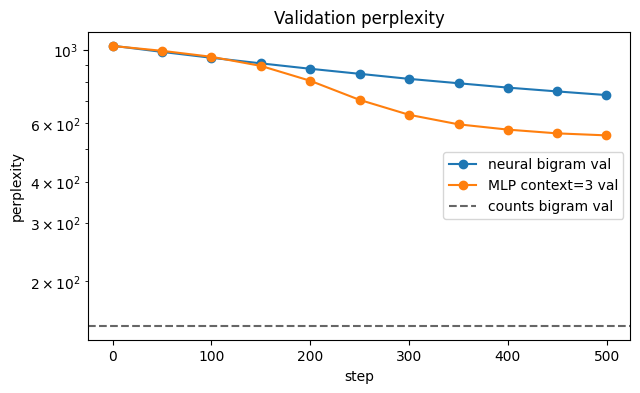

In [20]:
num_steps = 500
log_every = 50

counts_model = CountsBigramLM(vocab_size=vocab_size, smoothing=1.0)
counts_model.fit(train_ids)
counts_ppl = perplexity(counts_model, val_ids)

neural_model = NeuralBigramLM(vocab_size=vocab_size, embedding_dim=32)
neural_history = train_lm(
    neural_model,
    train_ids,
    val_ids=val_ids,
    batch_size=64,
    num_steps=num_steps,
    lr=0.4,
    log_every=log_every,
    device=experiment_device,
    generator=torch.Generator().manual_seed(1),
)

mlp_model = MLPLanguageModel(
    vocab_size=vocab_size,
    context_length=3,
    embedding_dim=32,
    hidden_dim=64,
)
mlp_history = train_lm(
    mlp_model,
    train_ids,
    val_ids=val_ids,
    batch_size=64,
    num_steps=num_steps,
    lr=0.25,
    log_every=log_every,
    device=experiment_device,
    generator=torch.Generator().manual_seed(2),
)

results = [
    ("counts bigram", counts_ppl),
    ("neural bigram", neural_history["val_perplexities"][-1]),
    ("MLP context=3", mlp_history["val_perplexities"][-1]),
]

print("model              validation perplexity")
print("-" * 40)
for name, ppl in results:
    print(f"{name:18s} {ppl:10.3f}")

train_steps = list(range(0, num_steps, log_every))
if train_steps[-1] != num_steps - 1:
    train_steps.append(num_steps - 1)

plt.figure(figsize=(7, 4))
plt.plot(train_steps, neural_history["val_perplexities"], marker="o", label="neural bigram val")
plt.plot(train_steps, mlp_history["val_perplexities"], marker="o", label="MLP context=3 val")
plt.axhline(counts_ppl, color="0.4", linestyle="--", label="counts bigram val")
plt.yscale("log")
plt.title("Validation perplexity")
plt.xlabel("step")
plt.ylabel("perplexity")
plt.legend()
plt.show()

## Exercise 6 - Sample From Each Model

Generation is the same next-token prediction loop run repeatedly. The text will be rough; the goal is to compare failure modes. The sampling cell uses a deliberately conservative display sampler: it masks out token IDs that never occurred in training, keeps only the top few candidates, and uses a low temperature so byte-level BPE noise does not dominate the comparison.

In [21]:
"Question: Which model's sample has the most locally plausible text? What evidence do you see?"
"Answer: "

"Question: What kinds of repetition or incoherence show up even in the best sample?"
"Answer: "

"Question: Why should none of these models produce long-range coherent prose yet?"
"Answer: "

'Answer: '

In [22]:
observed_token_ids = torch.unique(train_ids)
sample_prompt_text = "First Citizen:\n" if "First Citizen:" in text else "the model "


def sample_readable_tokens(
    model,
    prompt_ids: torch.Tensor,
    num_tokens: int,
    *,
    temperature: float = 0.55,
    top_k: int = 12,
    generator: torch.Generator | None = None,
) -> torch.Tensor:
    """Conservative notebook sampler for easier-to-read qualitative comparisons."""
    ctx_len = model.context_length
    out = list(prompt_ids.tolist())
    for _ in range(num_tokens):
        device = getattr(model, "device", torch.device("cpu"))
        ctx = torch.tensor(out[-ctx_len:], dtype=torch.long, device=device).unsqueeze(0)
        logits = model.logits(ctx)[0].detach().cpu()[observed_token_ids]
        candidate_ids = observed_token_ids
        if top_k is not None and top_k < logits.numel():
            logits, top_positions = torch.topk(logits, k=top_k)
            candidate_ids = observed_token_ids[top_positions]
        logits = logits / temperature
        probs = torch.softmax(logits, dim=-1)
        sampled_index = torch.multinomial(probs, num_samples=1, generator=generator).item()
        out.append(int(candidate_ids[sampled_index].item()))
    return torch.tensor(out, dtype=prompt_ids.dtype)


def decode_sample(model_name: str, model, *, temperature: float = 0.55, top_k: int = 12) -> None:
    prompt = torch.tensor(tokenizer.encode(sample_prompt_text), dtype=torch.long)
    if prompt.shape[0] < model.context_length:
        prompt = val_ids[: model.context_length]
    generated_ids = sample_readable_tokens(
        model,
        prompt_ids=prompt,
        num_tokens=160,
        temperature=temperature,
        top_k=top_k,
        generator=torch.Generator().manual_seed(10 + model.context_length),
    )
    print(f"\n--- {model_name} ---")
    print(tokenizer.decode(generated_ids.tolist()))


decode_sample("counts bigram", counts_model)
decode_sample("neural bigram", neural_model)
decode_sample("MLP context=3", mlp_model)


--- counts bigram ---
First Citizen:
And fir, former, the kingly seen, I know you
Wellowbreamine eyes,
LAUTI broth OF YORK:
ADudoth the curderer:
I cannot bell, as we do you more than a did I knows the great you to the soulden, if you our must be cons;
The s.

ISABELLA:
O, then, that the h, ife, I do not wathison the bale is thing and the say.
Sty soul,
But where the king,
AGody of theed intonguck, that he was the wely s;
But 

--- neural bigram ---
First Citizen:
std, e, sttineccsb, 
cb, s
stin
esin scbsb s, ss tsbs ttsdc wet
cdsdedeppp, , dsdb stecstb
d
, bin, bt, tcct,  t, s,  d,   ss
b bins, p,  ind ssddssst 
bstdin ds  eds sesdsstssbt, ein bs

--- MLP context=3 ---
First Citizen:
hds tins , dhasssend, tss intth, d ahasseetf, cenfaccedsinsinininetssfcinenc, , , hshsttin edinssind, te tin  eeinf fsa, dten tentastin,  hsentttc, ,  e ta, ahhdttt, , teh sinenen, estaeninhinfdinin, tcefts


## Exercise 7 - Plot Training Curves

Training loss and validation perplexity tell the same story in different units. Plot both and look for a gap between fitting the training stream and generalizing to held-out text.

In [17]:
"Question: Which curve is smoother: training loss or validation perplexity? Why might that be?"
"Answer: "

"Question: If validation perplexity rises while training loss falls, what does that suggest?"
"Answer: "

"Question: How would you modify the experiment to test whether more context helps?"
"Answer: "

'Answer: '

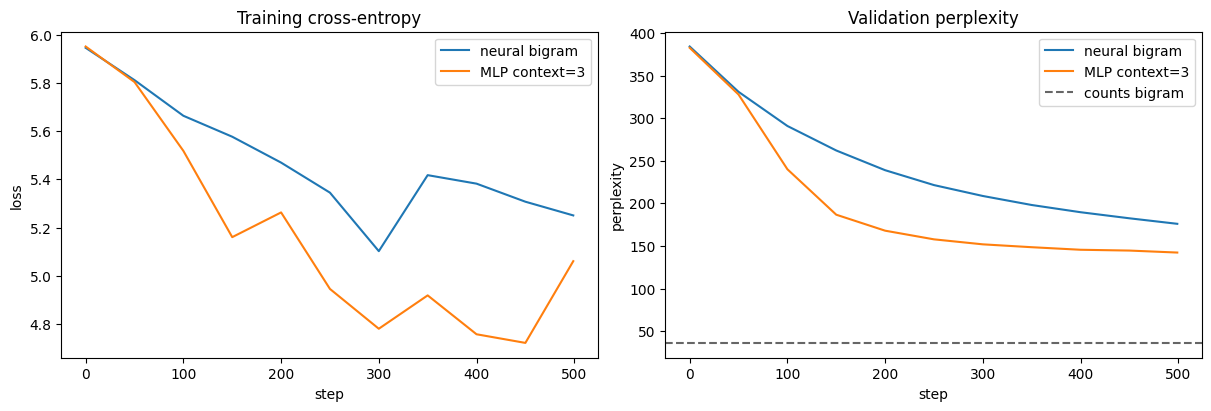

In [18]:
def logged_steps(num_steps: int, log_every: int) -> list[int]:
    steps = list(range(0, num_steps, log_every))
    final_step = num_steps - 1
    if steps[-1] != final_step:
        steps.append(final_step)
    return steps


steps = logged_steps(num_steps, log_every)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

axes[0].plot(steps, neural_history["train_losses"], label="neural bigram")
axes[0].plot(steps, mlp_history["train_losses"], label="MLP context=3")
axes[0].set_title("Training cross-entropy")
axes[0].set_xlabel("step")
axes[0].set_ylabel("loss")
axes[0].legend()

axes[1].plot(steps, neural_history["val_perplexities"], label="neural bigram")
axes[1].plot(steps, mlp_history["val_perplexities"], label="MLP context=3")
axes[1].axhline(counts_ppl, color="0.4", linestyle="--", label="counts bigram")
axes[1].set_title("Validation perplexity")
axes[1].set_xlabel("step")
axes[1].set_ylabel("perplexity")
axes[1].legend()

plt.show()